## Stage 1

In [56]:
import fastf1
import os
import pandas as pd
import plotly.express as px

In [2]:
cache_path = 'data/f1_cache'

In [3]:
os.makedirs(cache_path,exist_ok=True)

In [4]:
fastf1.Cache.enable_cache(cache_path)

In [5]:
session = fastf1.get_session(2023, 'Italy','R')

In [6]:
session.load()

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Driver 1 completed the race distance 06:25.888000 before the recorded end of the session.
core        WARNING 	Driver 11 completed the race distance 06:19.824000 before the recorded end of the session.
core        WARNING 	Driver 55 completed the race distance 06:14.695000 before the recorded end of the session.
core        WARNING 	Driver 16 

In [7]:
session.laps.shape

(957, 31)

In [8]:
session.laps['LapTime'].shape

(957,)

In [9]:
session.laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

## Stage 2

In [10]:
laps = session.laps

In [11]:
laps.isnull().sum()

Time                    0
Driver                  0
DriverNumber            0
LapTime                 9
LapNumber               0
Stint                   0
PitOutTime            932
PitInTime             931
Sector1Time            28
Sector2Time             9
Sector3Time             9
Sector1SessionTime     29
Sector2SessionTime      9
Sector3SessionTime      9
SpeedI1                 9
SpeedI2                 9
SpeedFL                35
SpeedST                 9
IsPersonalBest          9
Compound                0
TyreLife                0
FreshTyre               0
Team                    0
LapStartTime            0
LapStartDate            0
TrackStatus             0
Position                9
Deleted                 0
DeletedReason           9
FastF1Generated         0
IsAccurate              0
dtype: int64

In [12]:
clean_laps = laps.pick_quicklaps()

In [13]:
clean_laps['LapTimeSeconds'] = clean_laps['LapTime'].dt.total_seconds()

/var/folders/ht/f3q_ryx54sl_yb8g6gt_8fvc0000gn/T/ipykernel_95697/1745537734.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_laps['LapTimeSeconds'] = clean_laps['LapTime'].dt.total_seconds()


In [14]:
clean_laps[['LapTime','LapTimeSeconds']].sample(5)

,LapTime,LapTimeSeconds
250,0 days 00:01:27.371000,87.371
27,0 days 00:01:25.434000,85.434
57,0 days 00:01:27.210000,87.210
11,0 days 00:01:26.442000,86.442
302,0 days 00:01:27.590000,87.590


In [15]:
clean_laps['Driver'].value_counts()

Driver
VER    50
PER    50
LEC    49
RUS    49
ALB    49
SAI    49
NOR    48
ALO    48
HAM    48
BOT    47
SAR    47
PIA    46
STR    46
LAW    45
HUL    45
GAS    45
MAG    45
ZHO    45
OCO    35
Name: count, dtype: int64

In [16]:
clean_laps['Compound'].unique()

array(['MEDIUM', 'HARD'], dtype=object)

In [17]:
idx = clean_laps['LapTime'].idxmin()

In [18]:
clean_laps.loc[idx,['Driver','LapTimeSeconds']]

Driver               PIA
LapTimeSeconds    85.072
dtype: object

In [19]:
clean_laps['LapNumber'].min()

1.0

In [20]:
track_status = [status for status in clean_laps['TrackStatus'] if status != '1']

In [21]:
len(track_status)

0

In [22]:
clean_laps['TrackStatus'].value_counts()

TrackStatus
1    886
Name: count, dtype: int64

In [23]:
clean_laps = clean_laps[
    (clean_laps['LapNumber'] != 1) &
    (clean_laps['TrackStatus'] == '1')
]

In [24]:
clean_laps.shape

(879, 32)

In [132]:
tyre_deg = clean_laps.groupby('TyreLife')['LapTimeSeconds'].mean().reset_index()

In [134]:
team_pace = clean_laps.groupby('Team')['LapTimeSeconds'].mean().sort_values(ascending=True).reset_index()

In [41]:
clean_laps.groupby('Compound')['LapTimeSeconds'].agg(['mean', 'count'])

,mean,count
Compound,,
HARD,86.895444,473
MEDIUM,87.030778,406


In [55]:
clean_laps.groupby('Team').get_group('Red Bull Racing')['LapTimeSeconds'].mean() - clean_laps.groupby('Team').get_group('Ferrari')['LapTimeSeconds'].mean()

np.float64(-0.06468728741496932)

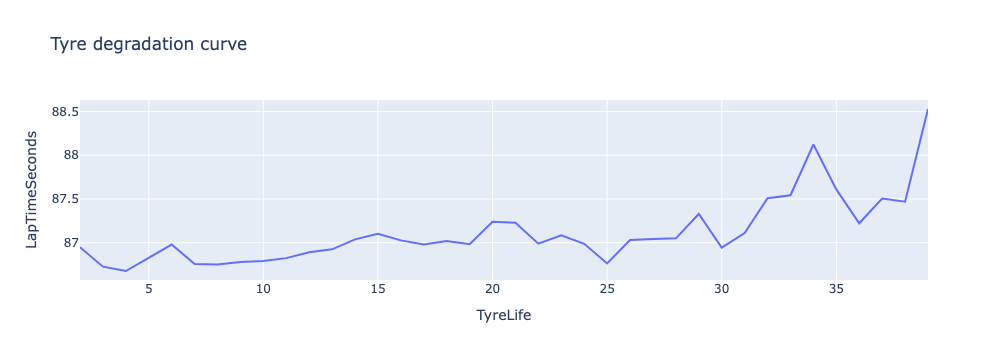

In [147]:
fig_1 = px.line(tyre_deg, x ='TyreLife', y = 'LapTimeSeconds' , title='Tyre degradation curve')
fig_1.show()

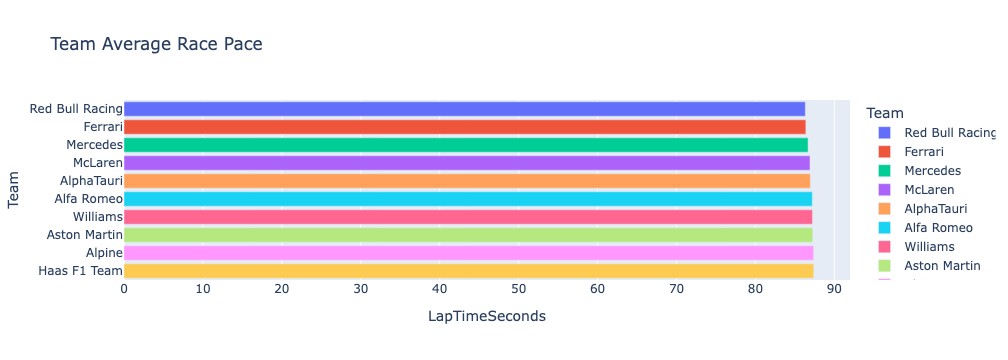

In [149]:
fig_2 = px.bar(team_pace, x = 'LapTimeSeconds',
               y = 'Team',
               color= 'Team',
               orientation='h',
               title='Team Average Race Pace'
    )
fig_2.show()

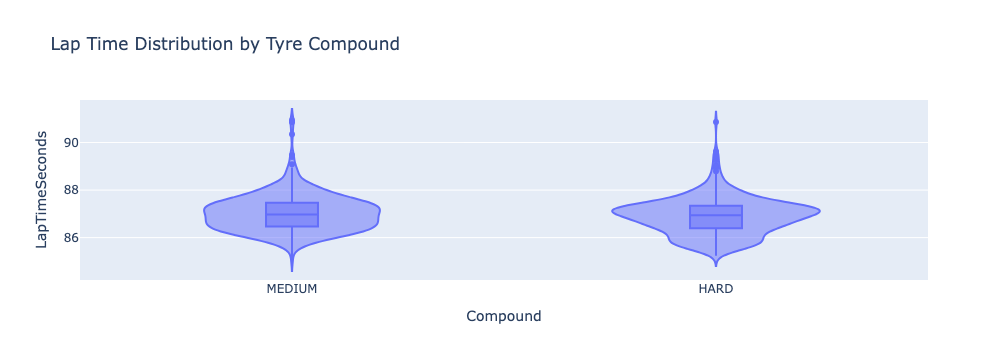

In [150]:
fig_3 = px.violin(clean_laps,
                  x= 'Compound',
                  y= 'LapTimeSeconds',
                  box= True ,
                  title= 'Lap Time Distribution by Tyre Compound')
fig_3.show()

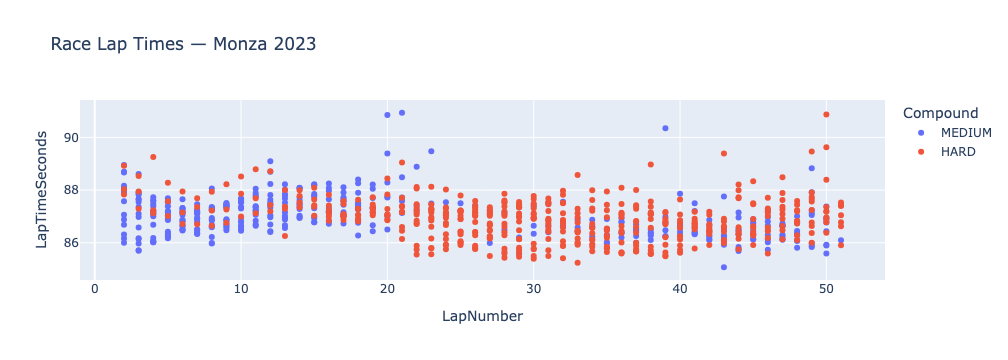

In [153]:
fig_4 = px.scatter(clean_laps,
                   x = 'LapNumber',
                   y = 'LapTimeSeconds',
                   hover_data=['Driver', 'Team'],
                   color='Compound',
                   title='Race Lap Times — Monza 2023')
fig_4.show()